Authors: [Maxime Devanne](https://maxime-devanne.com), [Germain Forestier](https://germain-forestier.info/), [Hassan Ismail Fawaz](https://hfawaz.github.io) and [Jonathan Weber](http://jonathan-weber.eu/)

# Regularization in Neural Networks

## Import modules

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

##MNIST dataset

### Load MNIST dataset

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# reduce size of train to speedup the training
nnn=1000
x_train = x_train[:nnn]
y_train = y_train[:nnn]

print("x_train",x_train.shape)
print("Number of images for train:",x_train.shape[0])
print("Number of images for test:",x_test.shape[0])
print("Size of an image:",x_train.shape[1:],"which makes:",
      x_train.shape[1]*x_train.shape[2],"pixels")
print("List of classes:",np.unique(y_train))

x_train (1000, 28, 28)
Number of images for train: 1000
Number of images for test: 10000
Size of an image: (28, 28) which makes: 784 pixels
List of classes: [0 1 2 3 4 5 6 7 8 9]


### View some images specifying that it is black and white

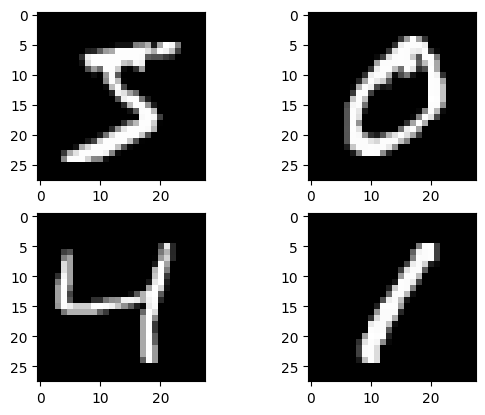

In [5]:
plt.subplot(221)
plt.imshow(x_train[0], cmap=plt.get_cmap('gray'))
plt.subplot(222)
plt.imshow(x_train[1], cmap=plt.get_cmap('gray'))
plt.subplot(223)
plt.imshow(x_train[2], cmap=plt.get_cmap('gray'))
plt.subplot(224)
plt.imshow(x_train[3], cmap=plt.get_cmap('gray'))
# show the plot
plt.show()

### Normalize the data so that each pixel is between 0 and 1

In [6]:
# divide by 255 so everything is in [0;1]
x_train = x_train/255
x_test = x_test/255

### Transform classes into binary representation(one-hot encoding)

In [7]:
y_train_binary = to_categorical(y_train)
y_test_binary = to_categorical(y_test)

### Transform the shape of the images (add an empty dimension to say that we have only one channel - gray instead of three for RGB like color images)

In [8]:
print(x_train.shape)
x_train = x_train.reshape(x_train.shape[0],x_train.shape[1],x_train.shape[2],1)
print(x_train.shape)
# same for test set
x_test = x_test.reshape(x_test.shape[0],x_test.shape[1],x_test.shape[2],1)

(1000, 28, 28)
(1000, 28, 28, 1)


## First original CNN model

### Building a new convolutional model with two layers and a softmax classifier as output

In [9]:
# input layer
input_shape = x_train.shape[1:]
input_layer = keras.layers.Input(input_shape)

# convolutional layer 1
hidden_conv_layer_1 = keras.layers.Conv2D(filters=10,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid',activation='relu')(input_layer)
# max pooling
hidden_pooling_layer_1 = keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                                  padding='valid')(hidden_conv_layer_1)

# convolution layer 2
hidden_conv_layer_2 = keras.layers.Conv2D(filters=20,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid', activation='relu')(hidden_pooling_layer_1)

# max pooling
hidden_pooling_layer_2 = keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                            padding='valid')(hidden_conv_layer_2)

# flatten
flatenned_layer_2 = keras.layers.Flatten()(hidden_pooling_layer_2)

nb_classes= len(np.unique(y_train))

# output layer
output_layer = keras.layers.Dense(units=nb_classes,activation='softmax')(flatenned_layer_2)

# a model linking input and output
model_mnist = keras.models.Model(inputs=input_layer, outputs=output_layer)

# optimization algorithm
optimizer_algo = keras.optimizers.SGD(learning_rate=0.1)

# loss function
cost_function = keras.losses.categorical_crossentropy

# model compilation
model_mnist.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

# model visualization
model_mnist.summary()

I0000 00:00:1772543898.331341  989988 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22129 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:09:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 20)       │         5,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         3,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,490 (33.16 KB)

 Trainable params: 8,490 (33.16 KB)

 Non-trainable params: 0 (0.00 B)

### Run model training and plot curves

2026-03-03 14:18:19.059192: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f13f0005c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-03 14:18:19.059207: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-03-03 14:18:19.071537: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-03 14:18:19.106896: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
I0000 00:00:1772543900.230624 1019036 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


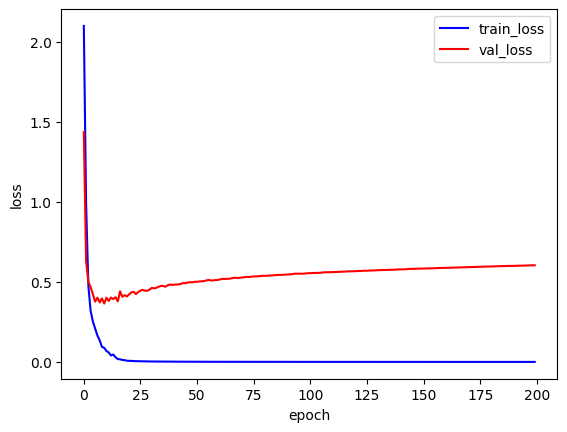

In [10]:
mini_batch_size = 32
nb_epochs = 200

percentage_of_train_as_validation = 0.2
history = model_mnist.fit(x_train,y_train_binary,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation)

history_dict = history.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

### Evaluate the model on the test set

In [11]:
loss,acc = model_mnist.evaluate(x_test,y_test_binary,verbose=False)

print("Accuracy on the test set is:",acc)

Accuracy on the test set is: 0.9289000034332275


## Explicit Regularization

### Weights Decay

#### Building the same model with a L2 regularization in the second convolutional layer

In [12]:
# input layer
input_shape = x_train.shape[1:]
input_layer = keras.layers.Input(input_shape)

# convolutional layer 1
hidden_conv_layer_1 = keras.layers.Conv2D(filters=10,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid',activation='relu')(input_layer)
# max pooling
hidden_pooling_layer_1 = keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                                  padding='valid')(hidden_conv_layer_1)

# convolutional layer 2 with a L2 regulizer
hidden_conv_layer_2 = keras.layers.Conv2D(filters=20,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid', activation='relu',kernel_regularizer=keras.regularizers.l2(0.001))(hidden_pooling_layer_1)

# max pooling
hidden_pooling_layer_2 = keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                            padding='valid')(hidden_conv_layer_2)

# flatten
flatenned_layer_2 = keras.layers.Flatten()(hidden_pooling_layer_2)

nb_classes= len(np.unique(y_train))

# output layer
output_layer = keras.layers.Dense(units=nb_classes,activation='softmax')(flatenned_layer_2)

# model linking input and output
model_mnist_wd = keras.models.Model(inputs=input_layer, outputs=output_layer)

# optimization algorithm
optimizer_algo = keras.optimizers.SGD(learning_rate=0.1)

# loss function
cost_function = keras.losses.categorical_crossentropy

# model compilation
model_mnist_wd.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

# model visualization
model_mnist_wd.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 20)       │         5,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         3,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,490 (33.16 KB)

 Trainable params: 8,490 (33.16 KB)

 Non-trainable params: 0 (0.00 B)

#### Run model training and plot curves

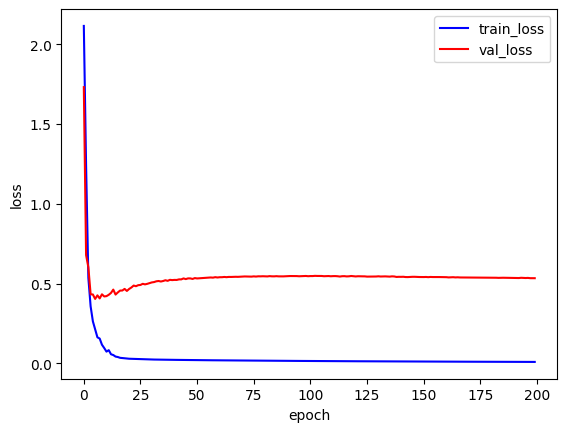

In [13]:
mini_batch_size = 32
nb_epochs = 200

percentage_of_train_as_validation = 0.3
history = model_mnist_wd.fit(x_train,y_train_binary,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation)

history_dict = history.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

#### Evaluate the model on the test set

In [14]:
loss,acc = model_mnist_wd.evaluate(x_test,y_test_binary,verbose=False)

print("Accuracy on the test set is:",acc)

Accuracy on the test set is: 0.9261000156402588


### Dropout

#### Same model with a Dropout

In [15]:
# input layer
input_shape = x_train.shape[1:]
input_layer = keras.layers.Input(input_shape)

# convolutional layer 1
hidden_conv_layer_1 = keras.layers.Conv2D(filters=10,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid',activation='relu')(input_layer)
# max pooling
hidden_pooling_layer_1 = keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                                  padding='valid')(hidden_conv_layer_1)

# convolutional layer 2 with a L2 regulizer
hidden_conv_layer_2 = keras.layers.Conv2D(filters=20,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid', activation='relu',kernel_regularizer=keras.regularizers.l2(0.01))(hidden_pooling_layer_1)

# max pooling
hidden_pooling_layer_2 = keras.layers.MaxPooling2D(pool_size=(2,2),strides=2,
                                            padding='valid')(hidden_conv_layer_2)

# dropout layer
dropout_layer_2 = keras.layers.Dropout(rate=0.5)(hidden_pooling_layer_2)

# flatten
flatenned_layer_2 = keras.layers.Flatten()(dropout_layer_2)

nb_classes= len(np.unique(y_train))

# output layer
output_layer = keras.layers.Dense(units=nb_classes,activation='softmax')(flatenned_layer_2)

# model linking input and output
model_mnist_wd_dropout = keras.models.Model(inputs=input_layer, outputs=output_layer)

# optimization algorithm
optimizer_algo = keras.optimizers.SGD(learning_rate=0.1)

# loss function
cost_function = keras.losses.categorical_crossentropy

# model compilation
model_mnist_wd_dropout.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

# model visualization
model_mnist_wd_dropout.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 10)     │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 20)       │         5,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         3,210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,490 (33.16 KB)

 Trainable params: 8,490 (33.16 KB)

 Non-trainable params: 0 (0.00 B)

#### Run model training and plot curves

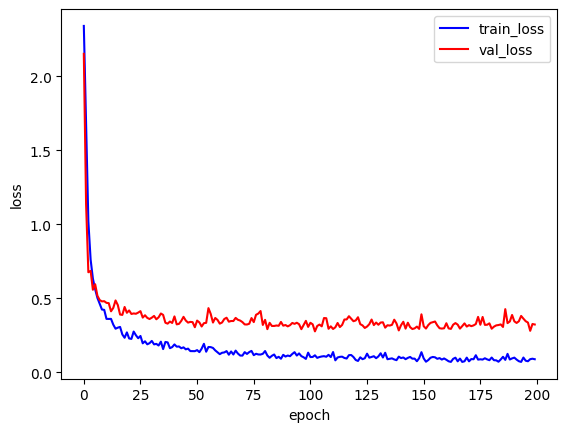

In [16]:
mini_batch_size = 32
nb_epochs = 200

percentage_of_train_as_validation = 0.2
history = model_mnist_wd_dropout.fit(x_train,y_train_binary,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation)

history_dict = history.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

#### Evaluate the model on the test set

In [17]:
loss,acc = model_mnist_wd_dropout.evaluate(x_test,y_test_binary,verbose=False)

print("Accuracy on the test set is:",acc)

Accuracy on the test set is: 0.9513000249862671


### Data augmentation

#### Define a generator which takes a data set as input and returns its augmentation

In [18]:
# use Keras datagenerator
datagen = keras.preprocessing.image.ImageDataGenerator(featurewise_center=True,
                                                       featurewise_std_normalization=True,
                                                       rotation_range=20, # random rotation angle
                                                       width_shift_range=0.1, #  horizontal shifting
                                                       height_shift_range = 0.1, # vertical shifting
                                                      )

#### Test the augmentation on 9 images to see

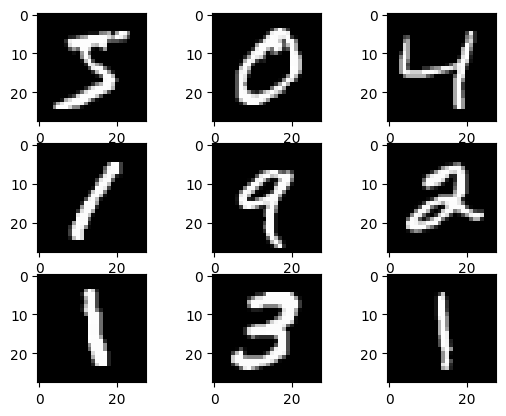

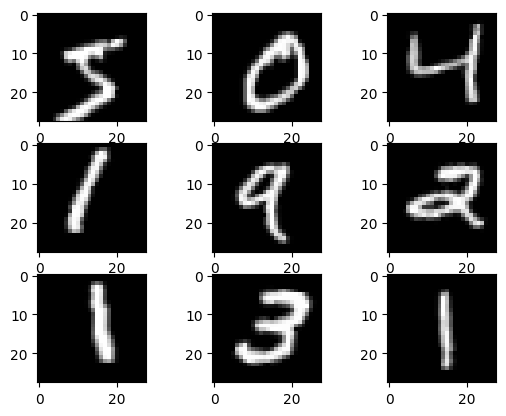

In [19]:
for i in range(0, 9):
	plt.subplot(330 + 1 + i)
	plt.imshow(x_train[i,:,:,0], cmap=plt.get_cmap('gray'))
# show the plot
plt.show()

# give the data to augment
datagen.fit(x_train,augment=True)

# iterate on online data augmentation
for x_batch, y_batch in datagen.flow(x_train,y_train,batch_size = 9,shuffle=False):
  # trace the one that has undergone a random modification
  for i in range(9):
    plt.subplot(330+1+i)
    plt.imshow(x_batch[i,:,:,0], cmap=plt.get_cmap('gray'))
  plt.show()
  plt.close()
  break

In [20]:
x_train_augmented_list = []
x_train_augmented_list.append(x_train)
y_train_augmented_list = []
y_train_augmented_list.append(y_train_binary)
for x_batch,y_batch in datagen.flow(x_train,y_train,batch_size=400):
  x_train_augmented_list.append(x_batch)
  y_batch_binary = to_categorical(y_batch)
  y_train_augmented_list.append(y_batch_binary)
  if len(x_train_augmented_list)>=5:
    break
x_train_augmented = np.concatenate(x_train_augmented_list)
y_train_augmented = np.concatenate(y_train_augmented_list)
print(x_train_augmented.shape)
print(y_train_augmented.shape)

(2400, 28, 28, 1)
(2400, 10)


### Create a two-layer convolutional model with the softmax classifier output
For seeing how to add an implicit regularization, we add a Batch normalization layer after the convolutional layers

In [21]:
# Create input layer
input_shape = x_train.shape[1:]
input_layer = keras.layers.Input(input_shape)

# Create convolutive layer
hidden_conv_layer_1 = keras.layers.Conv2D(filters=16,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid',activation='relu')(input_layer)
# create second convolutive layer
hidden_conv_layer_2 = keras.layers.Conv2D(filters=8,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid')(hidden_conv_layer_1)

# add a batch normalization layer before activation
batch_norm_layer_2 = keras.layers.BatchNormalization(axis=-1)(hidden_conv_layer_2)

# add activation reread
activation_layer_2 = keras.layers.Activation('relu')(batch_norm_layer_2)

# flatten the image
flatenned_layer_2 = keras.layers.Flatten()(activation_layer_2)

nb_classes= len(np.unique(y_train))

# create the output layer
output_layer = keras.layers.Dense(units=nb_classes,activation='softmax')(flatenned_layer_2)

# create the model by linking the input to the output
model_mnist_bn = keras.models.Model(inputs=input_layer, outputs=output_layer)

# visualize the model built
model_mnist_bn.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 20, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 20, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        32,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,666 (139.32 KB)

 Trainable params: 35,650 (139.26 KB)

 Non-trainable params: 16 (64.00 B)

**Why do we have 16 non-trainable parameters?**

### Train the model with the data augmentation

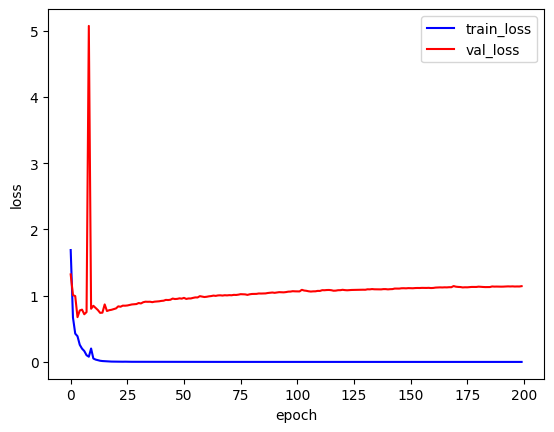

In [22]:
# choose the optimization algorithm
optimizer_algo = keras.optimizers.SGD(learning_rate=0.1)

# cost function that we want to optimize
cost_function = keras.losses.categorical_crossentropy

# compil model
model_mnist_bn.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

# mini batch size and number of epochs
mini_batch_size = 32
nb_epochs = 200

percentage_of_train_as_validation = 0.2
history = model_mnist_bn.fit(x_train_augmented,y_train_augmented,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation)

history_dict = history.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

### Evaluate on MNIST

In [23]:
loss,acc = model_mnist_bn.evaluate(x_test,y_test_binary,verbose=False)

print("Accuracy on test :",acc)

Accuracy on test : 0.9521999955177307


## Transfer learning

### Download a pre-trained model like VGG (example)

####  Using this [link](https://keras.io/applications)

In this session we are not going to use a downloaded model as they are usually quite expensive to train, but the example below shows you that it is very easy to retrieve a pre-trained model.

In [24]:
model_vgg = keras.applications.vgg16.VGG16(include_top=True, weights='imagenet', input_tensor=None, input_shape=None, pooling=None, classes=1000)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


#### Show information about this model

In [25]:
model_vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

### Fashion_MNIST dataset

Instead, we will explore how to use transfer learning of a simpler model between the Fashion MNIST dataset and the digit MNIST dataset

In [26]:
(x_train_fashion, y_train_fashion), (x_test_fashion, y_test_fashion) = fashion_mnist.load_data()

x_train_fashion = x_train_fashion[:1000]
y_train_fashion = y_train_fashion[:1000]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Show examples of the new dataset

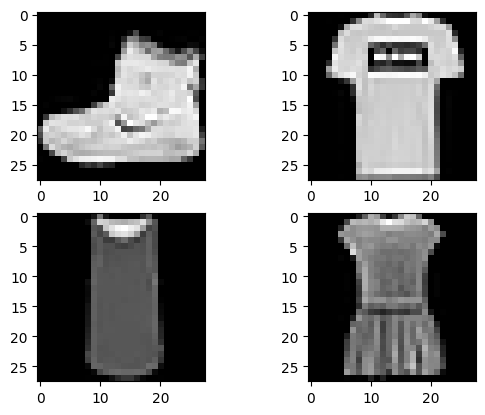

In [27]:
plt.subplot(221)
plt.imshow(x_train_fashion[0], cmap=plt.get_cmap('gray'))
plt.subplot(222)
plt.imshow(x_train_fashion[1], cmap=plt.get_cmap('gray'))
plt.subplot(223)
plt.imshow(x_train_fashion[2], cmap=plt.get_cmap('gray'))
plt.subplot(224)
plt.imshow(x_train_fashion[3], cmap=plt.get_cmap('gray'))
# show the plot
plt.show()

#### Normalize the data so that each pixel is between 0 and 1

In [28]:
x_train_fashion = x_train_fashion/255
x_test_fashion = x_test_fashion/255

#### Transform into one-hot encoding classes

In [29]:
y_train_fashion_binary = to_categorical(y_train_fashion)
y_test_fashion_binary = to_categorical(y_test_fashion)

#### Add an empty dimension to replace the RGB

In [30]:
print(x_train_fashion.shape)
x_train_fashion = x_train_fashion.reshape(x_train_fashion.shape[0],x_train_fashion.shape[1],x_train_fashion.shape[2],1)
print(x_train_fashion.shape)
x_test_fashion = x_test_fashion.reshape(x_test_fashion.shape[0],x_test_fashion.shape[1],x_test_fashion.shape[2],1)

(1000, 28, 28)
(1000, 28, 28, 1)


### Base model trained on Fashion MNIST

#### Create a base model as done previously

In [31]:
# Create input layer
input_shape = x_train_fashion.shape[1:]
input_layer = keras.layers.Input(input_shape)

# Create convolutive layer
hidden_conv_layer_1 = keras.layers.Conv2D(filters=16,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid',activation='relu')(input_layer)
# create second convolutive layer
hidden_conv_layer_2 = keras.layers.Conv2D(filters=8,
                                          kernel_size=(5,5) ,strides=1,
                                          padding='valid')(hidden_conv_layer_1)

# add a batch normalization layer before activation
batch_norm_layer_2 = keras.layers.BatchNormalization(axis=-1)(hidden_conv_layer_2)

# add activation reread
activation_layer_2 = keras.layers.Activation('relu')(batch_norm_layer_2)

# flatten the image
flatenned_layer_2 = keras.layers.Flatten()(activation_layer_2)

nb_classes= len(np.unique(y_train))

# create the output layer
output_layer = keras.layers.Dense(units=nb_classes,activation='softmax')(flatenned_layer_2)

# create the model by linking the input to the output
model_fashion_mnist_bn = keras.models.Model(inputs=input_layer, outputs=output_layer)

# visualize the model built
model_fashion_mnist_bn.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 24, 24, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 20, 20, 8)      │         3,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 20, 8)      │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 20, 20, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        32,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,666 (139.32 KB)

 Trainable params: 35,650 (139.26 KB)

 Non-trainable params: 16 (64.00 B)

#### Pre-train the model on the Fashion MNIST dataset

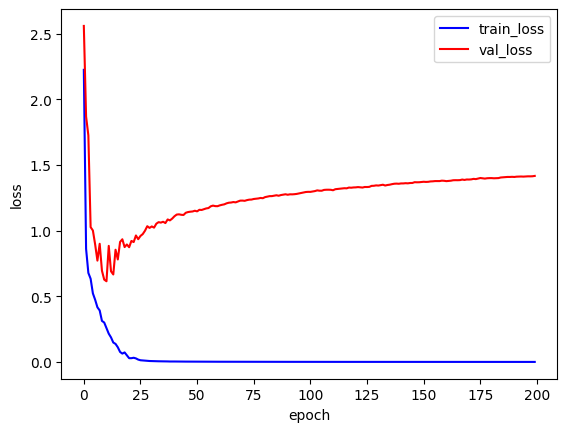

In [32]:
# choose the optimization algorithm
optimizer_algo = keras.optimizers.SGD(learning_rate=0.1)

# cost function that we want to optimize
cost_function = keras.losses.categorical_crossentropy

# compil model
model_fashion_mnist_bn.compile(loss=cost_function,optimizer=optimizer_algo, metrics=['accuracy'])

# mini batch size and number of epochs
mini_batch_size = 32
nb_epochs = 200

percentage_of_train_as_validation = 0.2
history = model_fashion_mnist_bn.fit(x_train_fashion,y_train_fashion_binary,batch_size=mini_batch_size,
                    epochs=nb_epochs,verbose=False,
                    validation_split=percentage_of_train_as_validation)

history_dict = history.history
loss_train_epochs = history_dict['loss']
loss_val_epochs = history_dict['val_loss']

plt.figure()
plt.plot(loss_train_epochs,color='blue',label='train_loss')
plt.plot(loss_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

#### Evaluate the model on Fashion_MNIST test set (just for information)

In [33]:
loss,acc = model_fashion_mnist_bn.evaluate(x_test_fashion,y_test_fashion_binary,verbose=False)

print("Accuracy on test :",acc)

Accuracy on test : 0.7817999720573425


### Transfer learning on the MNIST dataset

We first look at the performance of our new model on the MNIST dataset (remember that this model has never been trained on this dataset)

In [34]:
loss,acc = model_fashion_mnist_bn.evaluate(x_test,y_test_binary,verbose=False)

print("Accuracy on test :",acc)

Accuracy on test : 0.10920000076293945


#### fine-tune the model on the new dataset (MNIST)

In [35]:
history = model_fashion_mnist_bn.fit(x_train,y_train_binary,batch_size = 32, epochs=200, validation_split = 0.2, verbose=False)

#### Trace the variation of the accuracy on the train and on the validation set according to the number of epochs

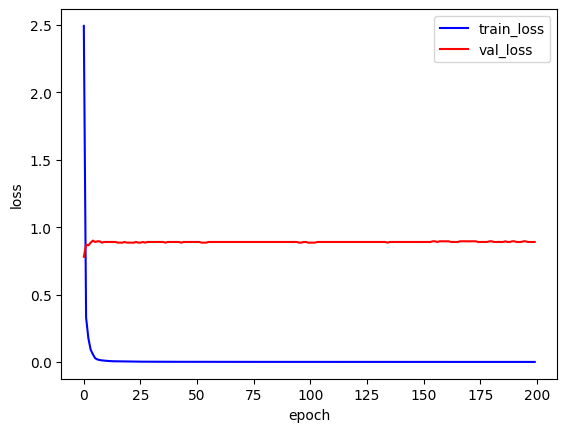

In [36]:
history_dict = history.history
acc_train_epochs = history_dict['loss']
acc_val_epochs = history_dict['val_accuracy']

plt.figure()
plt.plot(acc_train_epochs,color='blue',label='train_loss')
plt.plot(acc_val_epochs,color='red',label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.savefig('epoch-loss.pdf')
plt.show()
plt.close()

#### Evaluate the model on test set

In [37]:
loss,acc = model_fashion_mnist_bn.evaluate(x_test,y_test_binary,verbose=False)
print("Accuracy on test set is:",acc)

Accuracy on test set is: 0.9168999791145325


## **Exercice**

Train a model usgin regularization techniques on the Pokemon Images dataset

Using dataset files:
  X_train: /home/basile/documents/github/perso/deep-learning/regularization/X_train_hr.npy
  y_train: /home/basile/documents/github/perso/deep-learning/regularization/y_train_hr.npy
  X_test: /home/basile/documents/github/perso/deep-learning/regularization/X_test_hr.npy
  y_test: /home/basile/documents/github/perso/deep-learning/regularization/y_test_hr.npy

Data summary:
  x_train_all: (823, 255, 255, 3)
  y_train_all: (823, 12)
  x_test:      (206, 255, 255, 3)
  y_test:      (206, 12)
  num_classes: 12

Split summary:
  Train: 658 samples
  Val:   165 samples
  Test:  206 samples

Training baseline model (batch_size=128)
Epoch 1/200


2026-03-03 14:24:32.056389: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng57{k2=0,k13=2,k14=2,k18=1,k23=0} for conv (f32[32,3,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,3,255,255]{3,2,1,0}, f32[128,32,255,255]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-03-03 14:24:32.972645: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.916329384s
Trying algorithm eng57{k2=0,k13=2,k14=2,k18=1,k23=0} for conv (f32[32,3,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[128,3,255,255]{3,2,1,0}, f32[128,32,255,255]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target


Epoch 1: val_loss improved from None to 7.60643, saving model to best_pokemon_baseline.keras

Epoch 1: finished saving model to best_pokemon_baseline.keras
6/6 - 14s - 2s/step - accuracy: 0.1353 - loss: 22.7779 - val_accuracy: 0.0667 - val_loss: 7.6064 - learning_rate: 0.0010
Epoch 2/200

Epoch 2: val_loss improved from 7.60643 to 2.33491, saving model to best_pokemon_baseline.keras

Epoch 2: finished saving model to best_pokemon_baseline.keras
6/6 - 1s - 228ms/step - accuracy: 0.1368 - loss: 4.2493 - val_accuracy: 0.1273 - val_loss: 2.3349 - learning_rate: 0.0010
Epoch 3/200

Epoch 3: val_loss improved from 2.33491 to 1.95370, saving model to best_pokemon_baseline.keras

Epoch 3: finished saving model to best_pokemon_baseline.keras
6/6 - 1s - 225ms/step - accuracy: 0.2599 - loss: 2.1709 - val_accuracy: 0.2970 - val_loss: 1.9537 - learning_rate: 0.0010
Epoch 4/200

Epoch 4: val_loss improved from 1.95370 to 1.60125, saving model to best_pokemon_baseline.keras

Epoch 4: finished saving

2026-03-03 14:25:18.410929: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_190', 12 bytes spill stores, 12 bytes spill loads




Epoch 1: val_loss improved from None to 3.44534, saving model to best_pokemon_regularized.keras

Epoch 1: finished saving model to best_pokemon_regularized.keras
6/6 - 13s - 2s/step - accuracy: 0.2128 - loss: 2.6808 - val_accuracy: 0.1030 - val_loss: 3.4453 - learning_rate: 0.0010
Epoch 2/200

Epoch 2: val_loss improved from 3.44534 to 2.77052, saving model to best_pokemon_regularized.keras

Epoch 2: finished saving model to best_pokemon_regularized.keras
6/6 - 5s - 798ms/step - accuracy: 0.3495 - loss: 2.0908 - val_accuracy: 0.1576 - val_loss: 2.7705 - learning_rate: 0.0010
Epoch 3/200

Epoch 3: val_loss improved from 2.77052 to 2.33463, saving model to best_pokemon_regularized.keras

Epoch 3: finished saving model to best_pokemon_regularized.keras
6/6 - 5s - 803ms/step - accuracy: 0.4210 - loss: 1.8987 - val_accuracy: 0.2121 - val_loss: 2.3346 - learning_rate: 0.0010
Epoch 4/200

Epoch 4: val_loss improved from 2.33463 to 2.27352, saving model to best_pokemon_regularized.keras

Epoc

2026-03-03 14:26:57.274581: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_105', 12 bytes spill stores, 12 bytes spill loads




Comparison table:
      model  train_acc  val_acc  test_acc  test_loss
   baseline     0.9696   0.6667    0.7039     0.9137
regularized     0.2280   0.2121    0.2087     2.2816

Saved checkpoints: best_pokemon_baseline.keras, best_pokemon_regularized.keras
Baseline batch size used: 128
Regularized batch size used: 128


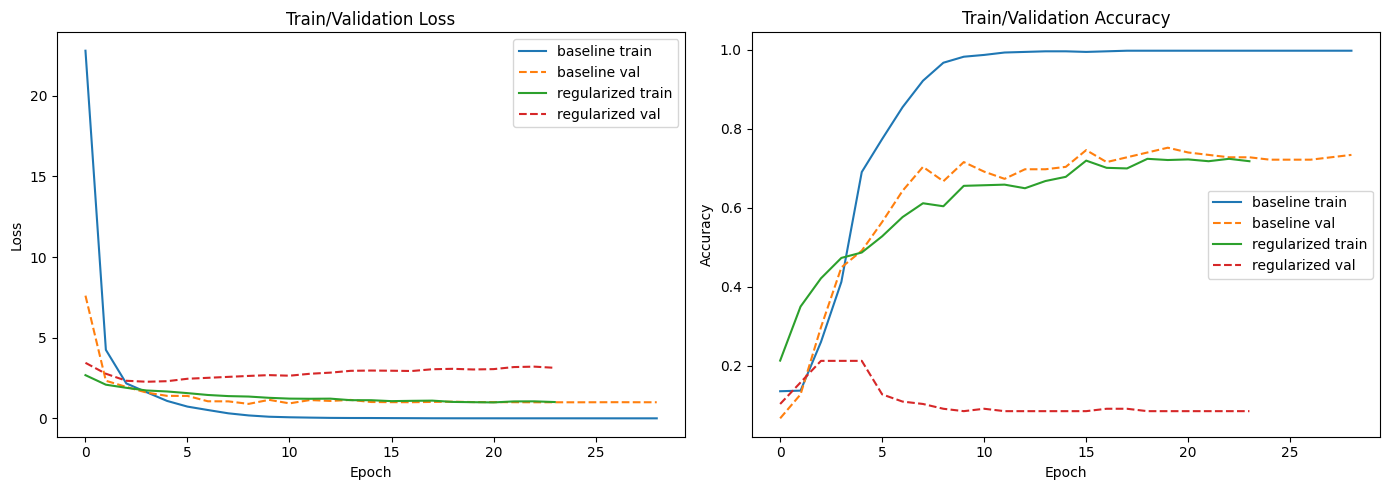

Confusion matrix shape: (12, 12)

Per-class metrics (regularized model on test set):
 class  precision  recall     f1  support
     0     0.0000  0.0000 0.0000        8
     1     0.0000  0.0000 0.0000       11
     2     0.0000  0.0000 0.0000       18
     3     0.0000  0.0000 0.0000       15
     4     0.2222  0.3077 0.2581       13
     5     1.0000  0.0556 0.1053       18
     6     0.0897  0.3889 0.1458       18
     7     0.0000  0.0000 0.0000       15
     8     0.0000  0.0000 0.0000       22
     9     0.2600  0.9286 0.4062       28
    10     0.5556  0.2273 0.3226       22
    11     0.0000  0.0000 0.0000       18

Macro averages:
  precision=0.1773, recall=0.1590, f1=0.1032


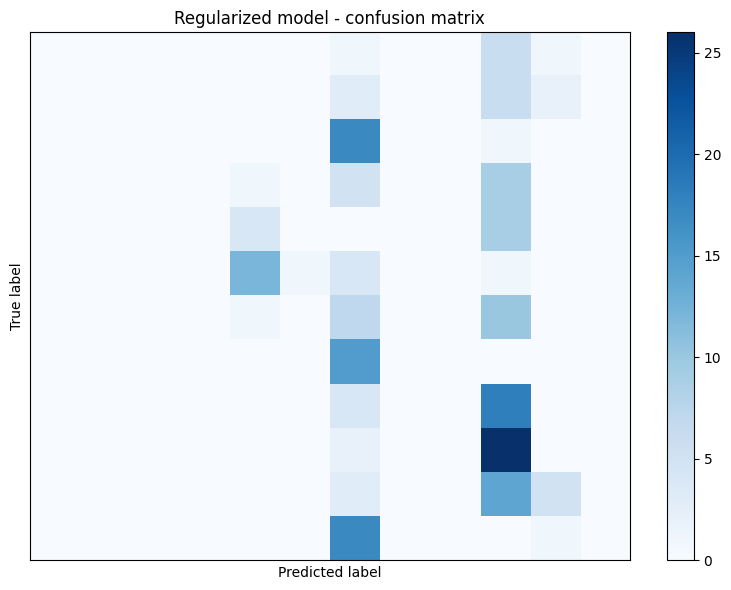

In [38]:
# Pokemon images regularization exercise: end-to-end baseline vs regularized CNN
import os
import math
import shutil
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset file names and sources
DATA_FILES = {
    "X_train": "X_train_hr.npy",
    "y_train": "y_train_hr.npy",
    "X_test": "X_test_hr.npy",
    "y_test": "y_test_hr.npy",
}
BASE_URL = "https://www.maxime-devanne.com/datasets/Pokemon_images"
DATA_URLS = {key: f"{BASE_URL}/{filename}" for key, filename in DATA_FILES.items()}
SEARCH_DIRS = [Path('.'), Path('../CNN')]
TARGET_DIR = Path('.')


def locate_dataset_files():
    """Find dataset files in known local locations."""
    located = {}
    for key, filename in DATA_FILES.items():
        for folder in SEARCH_DIRS:
            candidate = (folder / filename).resolve()
            if candidate.exists():
                located[key] = candidate
                break
    return located


def _download_file(url, destination):
    """Download one file with wget if available, otherwise urllib."""
    destination.parent.mkdir(parents=True, exist_ok=True)

    if shutil.which('wget'):
        cmd = ['wget', '-O', str(destination), url]
        proc = subprocess.run(cmd, capture_output=True, text=True)
        if proc.returncode == 0 and destination.exists() and destination.stat().st_size > 0:
            return
        raise RuntimeError(proc.stderr.strip() or proc.stdout.strip() or 'wget failed')

    # Fallback if wget is unavailable
    import urllib.request
    with urllib.request.urlopen(url, timeout=60) as response:
        destination.write_bytes(response.read())


def download_missing_files(missing_keys):
    """Download missing dataset files into current directory."""
    for key in missing_keys:
        dst = (TARGET_DIR / DATA_FILES[key]).resolve()
        print(f"Downloading {DATA_FILES[key]} from {DATA_URLS[key]}")
        _download_file(DATA_URLS[key], dst)


def labels_to_int_and_onehot(y, num_classes=None):
    """Handle integer labels and already one-hot labels."""
    y = np.asarray(y)

    if y.ndim == 1:
        y_int = y.astype('int64')
        if num_classes is None:
            num_classes = int(np.max(y_int)) + 1
        y_onehot = to_categorical(y_int, num_classes=num_classes)

    elif y.ndim == 2:
        if y.shape[1] == 1:
            y_int = y.reshape(-1).astype('int64')
            if num_classes is None:
                num_classes = int(np.max(y_int)) + 1
            y_onehot = to_categorical(y_int, num_classes=num_classes)
        else:
            y_int = np.argmax(y, axis=1).astype('int64')
            if num_classes is None:
                num_classes = y.shape[1]
            y_onehot = y.astype('float32')
            if y_onehot.shape[1] != int(num_classes):
                y_onehot = to_categorical(y_int, num_classes=num_classes)

    else:
        raise ValueError(f"Unsupported label shape: {y.shape}. Expected 1D or 2D labels.")

    return y_int, y_onehot.astype('float32'), int(num_classes)


def stratified_train_val_split(x, y_onehot, y_int, test_size=0.2, random_state=42):
    """Numpy-based stratified split to avoid external sklearn dependency."""
    rng = np.random.default_rng(random_state)
    y_int = np.asarray(y_int)

    train_idx = []
    val_idx = []

    for cls in np.unique(y_int):
        idx = np.where(y_int == cls)[0]
        rng.shuffle(idx)

        if len(idx) <= 1:
            train_idx.extend(idx.tolist())
            continue

        n_val = int(round(len(idx) * test_size))
        n_val = max(1, min(n_val, len(idx) - 1))

        val_idx.extend(idx[:n_val].tolist())
        train_idx.extend(idx[n_val:].tolist())

    train_idx = np.array(train_idx, dtype=np.int64)
    val_idx = np.array(val_idx, dtype=np.int64)

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)

    return (
        x[train_idx], x[val_idx],
        y_onehot[train_idx], y_onehot[val_idx],
        y_int[train_idx], y_int[val_idx],
    )


# Resolve dataset files: local first, then auto-download
paths = locate_dataset_files()
missing = [key for key in DATA_FILES if key not in paths]

if missing:
    print('Missing local files:', [DATA_FILES[k] for k in missing])
    try:
        download_missing_files(missing)
    except Exception as exc:
        missing_names = ', '.join(DATA_FILES[k] for k in missing)
        raise FileNotFoundError(
            'Could not find/download Pokemon dataset files. '
            f'Missing: {missing_names}. '
            'Place them in the current directory or in ../CNN and rerun this cell.'
        ) from exc

    paths = locate_dataset_files()
    missing = [key for key in DATA_FILES if key not in paths]

if missing:
    missing_names = ', '.join(DATA_FILES[k] for k in missing)
    raise FileNotFoundError(
        f'Dataset files are still missing after download attempt: {missing_names}. '
        'Place files in current directory or ../CNN.'
    )

print('Using dataset files:')
for key in DATA_FILES:
    print(f"  {key}: {paths[key]}")

# Load data
X_train = np.load(paths['X_train'], allow_pickle=False)
y_train_raw = np.load(paths['y_train'], allow_pickle=False)
X_test = np.load(paths['X_test'], allow_pickle=False)
y_test_raw = np.load(paths['y_test'], allow_pickle=False)

# Basic validation
if X_train.shape[0] != np.asarray(y_train_raw).shape[0]:
    raise ValueError(f"Mismatch: X_train has {X_train.shape[0]} samples, y_train has {np.asarray(y_train_raw).shape[0]}")
if X_test.shape[0] != np.asarray(y_test_raw).shape[0]:
    raise ValueError(f"Mismatch: X_test has {X_test.shape[0]} samples, y_test has {np.asarray(y_test_raw).shape[0]}")
if X_train.ndim != 4 or X_test.ndim != 4:
    raise ValueError(f"Expected 4D image tensors (N,H,W,C). Got X_train={X_train.shape}, X_test={X_test.shape}")

# Normalize images to [0, 1]
x_train_all = X_train.astype('float32') / 255.0
x_test = X_test.astype('float32') / 255.0

# Labels: robust conversion
y_train_int, y_train_all, num_classes = labels_to_int_and_onehot(y_train_raw)
y_test_int, y_test, _ = labels_to_int_and_onehot(y_test_raw, num_classes=num_classes)

print()
print('Data summary:')
print(f'  x_train_all: {x_train_all.shape}')
print(f'  y_train_all: {y_train_all.shape}')
print(f'  x_test:      {x_test.shape}')
print(f'  y_test:      {y_test.shape}')
print(f'  num_classes: {num_classes}')

# Train/validation split (test set untouched)
x_train, x_val, y_train, y_val, y_train_int_split, y_val_int = stratified_train_val_split(
    x_train_all,
    y_train_all,
    y_train_int,
    test_size=0.2,
    random_state=SEED,
)

print()
print('Split summary:')
print(f'  Train: {x_train.shape[0]} samples')
print(f'  Val:   {x_val.shape[0]} samples')
print(f'  Test:  {x_test.shape[0]} samples')


def build_baseline_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='pokemon_baseline')
    return model


def build_regularized_model(input_shape, num_classes):
    wd = 1e-4
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(
        32,
        (3, 3),
        padding='same',
        use_bias=False,
        kernel_regularizer=keras.regularizers.l2(wd),
    )(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(
        64,
        (3, 3),
        padding='same',
        use_bias=False,
        kernel_regularizer=keras.regularizers.l2(wd),
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, use_bias=False, kernel_regularizer=keras.regularizers.l2(wd))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.50)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name='pokemon_regularized')
    return model


def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


def make_callbacks(checkpoint_path):
    return [
        keras.callbacks.ModelCheckpoint(
            checkpoint_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1,
        ),
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1,
        ),
    ]




def ensure_tf_range_op_available():
    """
    Work around broken TensorFlow builds where
    `from tensorflow.python.data.ops import range_op` fails.
    """
    try:
        from tensorflow.python.data.ops import range_op  # noqa: F401
        return
    except Exception:
        import importlib
        import sys
        import types

        pkg_name = 'tensorflow.python.data.ops'
        pkg = sys.modules.get(pkg_name)
        if pkg is None:
            pkg = importlib.import_module(pkg_name)

        mod_name = f'{pkg_name}.range_op'
        if mod_name in sys.modules:
            setattr(pkg, 'range_op', sys.modules[mod_name])
            return

        range_mod = types.ModuleType(mod_name)

        def _range(*args, **kwargs):
            tensor = tf.range(*args, **kwargs)
            return tf.data.Dataset.from_tensor_slices(tensor)

        range_mod._range = _range
        sys.modules[mod_name] = range_mod
        setattr(pkg, 'range_op', range_mod)


def fit_with_rangeop_recovery(model, *fit_args, **fit_kwargs):
    """Retry model.fit after patching missing tensorflow.python.data.ops.range_op."""
    try:
        return model.fit(*fit_args, **fit_kwargs)
    except ImportError as exc:
        if 'range_op' not in str(exc):
            raise
        print('Detected TensorFlow range_op import issue. Applying compatibility patch and retrying fit...')
        ensure_tf_range_op_available()
        return model.fit(*fit_args, **fit_kwargs)

input_shape = x_train.shape[1:]
EPOCHS = 200
batch_size_candidates = [128, 64]
BASELINE_CKPT = 'best_pokemon_baseline.keras'
REGULARIZED_CKPT = 'best_pokemon_regularized.keras'

# Train baseline model with batch-size fallback
history_baseline = None
baseline_batch_size = None
for bs in batch_size_candidates:
    try:
        print()
        print(f"Training baseline model (batch_size={bs})")
        baseline_model = compile_model(build_baseline_model(input_shape, num_classes))
        history_baseline = fit_with_rangeop_recovery(baseline_model,
            x_train,
            y_train,
            epochs=EPOCHS,
            batch_size=bs,
            validation_data=(x_val, y_val),
            callbacks=make_callbacks(BASELINE_CKPT),
            verbose=2,
        )
        baseline_batch_size = bs
        break
    except tf.errors.ResourceExhaustedError:
        print(f"Baseline model ran out of memory with batch_size={bs}. Retrying with smaller batch size.")
        continue

if history_baseline is None:
    raise RuntimeError('Baseline model training failed for all batch size candidates.')

# Data augmentation for regularized model
datagen = keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
)
datagen.fit(x_train, augment=True, seed=SEED)

# Train regularized model with batch-size fallback
history_regularized = None
regularized_batch_size = None
for bs in batch_size_candidates:
    try:
        print()
        print(f"Training regularized model (batch_size={bs})")
        regularized_model = compile_model(build_regularized_model(input_shape, num_classes))
        train_flow = datagen.flow(x_train, y_train, batch_size=bs, shuffle=True, seed=SEED)
        steps_per_epoch = int(math.ceil(x_train.shape[0] / bs))

        history_regularized = fit_with_rangeop_recovery(regularized_model,
            train_flow,
            epochs=EPOCHS,
            steps_per_epoch=steps_per_epoch,
            validation_data=(x_val, y_val),
            callbacks=make_callbacks(REGULARIZED_CKPT),
            verbose=2,
        )
        regularized_batch_size = bs
        break
    except tf.errors.ResourceExhaustedError:
        print(f"Regularized model ran out of memory with batch_size={bs}. Retrying with smaller batch size.")
        continue

if history_regularized is None:
    raise RuntimeError('Regularized model training failed for all batch size candidates.')

# Load best checkpoints
baseline_best = keras.models.load_model(BASELINE_CKPT)
regularized_best = keras.models.load_model(REGULARIZED_CKPT)


def evaluate_model_on_splits(model, model_name):
    train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
    val_loss, val_acc = model.evaluate(x_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return {
        'model': model_name,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'test_loss': test_loss,
    }


results = [
    evaluate_model_on_splits(baseline_best, 'baseline'),
    evaluate_model_on_splits(regularized_best, 'regularized'),
]
results_df = pd.DataFrame(results, columns=['model', 'train_acc', 'val_acc', 'test_acc', 'test_loss'])

print()
print('Comparison table:')
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print()
print(f"Saved checkpoints: {BASELINE_CKPT}, {REGULARIZED_CKPT}")
print(f"Baseline batch size used: {baseline_batch_size}")
print(f"Regularized batch size used: {regularized_batch_size}")

# Plot training curves (loss and accuracy)
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'], label='baseline train')
plt.plot(history_baseline.history['val_loss'], '--', label='baseline val')
plt.plot(history_regularized.history['loss'], label='regularized train')
plt.plot(history_regularized.history['val_loss'], '--', label='regularized val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Train/Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'], label='baseline train')
plt.plot(history_baseline.history['val_accuracy'], '--', label='baseline val')
plt.plot(history_regularized.history['accuracy'], label='regularized train')
plt.plot(history_regularized.history['val_accuracy'], '--', label='regularized val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Train/Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Optional: final regularized model diagnostics
y_test_pred = np.argmax(regularized_best.predict(x_test, verbose=0), axis=1)

cm = tf.math.confusion_matrix(y_test_int, y_test_pred, num_classes=num_classes).numpy()
print(f'Confusion matrix shape: {cm.shape}')

# Simple per-class precision/recall/F1 summary without sklearn
true_pos = np.diag(cm).astype('float64')
pred_pos = cm.sum(axis=0).astype('float64')
real_pos = cm.sum(axis=1).astype('float64')

precision = np.divide(true_pos, pred_pos, out=np.zeros_like(true_pos), where=pred_pos != 0)
recall = np.divide(true_pos, real_pos, out=np.zeros_like(true_pos), where=real_pos != 0)
f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) != 0)

metrics_df = pd.DataFrame({
    'class': np.arange(num_classes),
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'support': real_pos.astype(int),
})

print()
print('Per-class metrics (regularized model on test set):')
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
print('Macro averages:')
print(f"  precision={precision.mean():.4f}, recall={recall.mean():.4f}, f1={f1.mean():.4f}")

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues', aspect='auto')
plt.title('Regularized model - confusion matrix')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.tight_layout()
plt.show()
